In [1]:
%matplotlib inline
from IPython.display import Image, display
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from custom_datasets import _make_loader, make_label_drop_subset, make_recovered_target_replay_subset
from FRPT import get_score, save_recons_fea_to_h5
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:1


In [2]:
"""数据"""
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.1307,),  std=(0.3081,)),
])

train_set = datasets.MNIST("/data/dn/FRTP_revision1/mydata", train=True, download=True, transform=transform)
test_set = datasets.MNIST("/data/dn/FRTP_revision1/mydata", train=False, download=True, transform=transform)
print(len(train_set),len(test_set))
BATCH_SIZE = 256
NUM_WORKERS = 4

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) 
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False) 


# TARGET_LABEL = 4
# DROP_RATIO = 0.90
# REPLAY_RATIO = 0.50
# seed = 42
# pretrain_train_set, pretrain_info = make_label_drop_subset(
#     train_set, target_label=TARGET_LABEL, drop_ratio=DROP_RATIO, seed=seed)
# posttrain_train_set, posttrain_info = make_recovered_target_replay_subset(
#         train_set, target_label=TARGET_LABEL,
#         recovered_target_indices=pretrain_train_set.dropped_target_indices,
#         replay_ratio=REPLAY_RATIO,seed=seed + 1,)
# train_loader = _make_loader(pretrain_train_set, BATCH_SIZE, True, NUM_WORKERS, pin_memory=None)
# test_loader = _make_loader(test_set, BATCH_SIZE, False, NUM_WORKERS, pin_memory=None)
# # posttrain_train_loader = _make_loader(posttrain_train_set, BATCH_SIZE, True, NUM_WORKERS, pin_memory=None)
# posttrain_train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) 

# print(len(train_loader), len(test_loader))

60000 10000


In [3]:
def train_base(model, trainloader, testloader, optimizer, num_epochs, es_patience=5, scheduler=None):
    # if scheduler is None:
    #     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #         optimizer, mode='max', factor=0.5, patience=3, threshold=0.0, min_lr=1e-6
    #     )

    test_acc_ls, loss_ls, train_acc_ls = [], [], []
    best_acc, best_ckpt, wait = -1.0, None, 0

    criterion = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        model.train()
        epoch_loss, sample_num = 0.0, 0

        for x, y in trainloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x)['out'], y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            epoch_loss += loss.item() * bs
            sample_num += bs

        epoch_loss /= sample_num
        loss_ls.append(epoch_loss)

        train_acc = get_score(model, trainloader, DEVICE, target_label=TARGET_LABEL) # use?
        if isinstance(train_acc, dict): train_acc = train_acc['overall_acc']
        train_acc_ls.append(train_acc)
        test_acc = get_score(model, testloader, DEVICE, target_label=TARGET_LABEL)
        if isinstance(test_acc, dict): test_acc = test_acc['overall_acc']
        test_acc_ls.append(test_acc)
        lr = optimizer.param_groups[0]['lr']
        if len(train_acc_ls):
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}, Train Accuracy: {train_acc_ls[-1]:.4f}, Test Accuracy: {test_acc:.4f}, LR: {lr:.2e}')
        else:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}, Test Accuracy: {test_acc:.4f}, LR: {lr:.2e}')

        # 每 10 个 epoch 保存一次当前模型的 checkpoint（包含 epoch 和 test_acc 信息）
        if ((epoch + 1) % 10 == 0 and (epoch + 1) not in []) or (epoch+1) == num_epochs:
            ckpt_dir = Path("/data/dn/FRTP_revision1/imagecls/ckpts_ood/mnist")
            periodic_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if ckpt_dir is not None:
                name = getattr(model, 'name', model.__class__.__name__)
                fname = ckpt_dir / f"{name}_target{TARGET_LABEL}_drop{DROP_RATIO}_e{epoch+1}_{test_acc:.4f}.pth"
                try:
                    torch.save(periodic_ckpt, str(fname))
                    print(f"Saved periodic checkpoint to {fname}")
                except Exception as e:
                    print(f"Failed saving periodic checkpoint: {e}")

        if scheduler is not None:
            scheduler.step(test_acc)
            if test_acc > best_acc:
                best_acc = test_acc
                best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= es_patience:
                    print(f'Early stopping at epoch {epoch+1}. Best Test Accuracy: {best_acc:.4f}')
                    break
    if scheduler is not None and best_ckpt is not None:
        model.load_state_dict(best_ckpt)
    return loss_ls, train_acc_ls, test_acc_ls, best_ckpt

## baseline

In [ ]:
"""train baseline model """
from models import SimpleCNN_mn, ResNet_mn
model = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
model.load_state_dict(torch.load("/data/dn/FRTP_revision1/imagecls/ckpts/mnist/mn_simplecnnv2_relu_target4_drop0.9_e30_0.9670.pth", map_location=DEVICE))
# model = ResNet_mn(version="18", pretrain=False).to(DEVICE)
optimizer_ = torch.optim.AdamW(model.parameters(), lr=0.001)
epoches = 10
loss_lt, trainacc_lt, testacc_lt, best_ckpt = train_base(model, train_loader, test_loader, optimizer_, epoches)  # TODO 这里调参
print("baseline_loss.extend(")
print(loss_lt)
print("baseline_testacc.extend(")
print(testacc_lt)
# torch.save(best_ckpt, f"/data/dn/FRTP_revision1/imagecls/ckpts/mnist/{model.name}_{max(testacc_lt):.4f}.pth")

## get recons features

In [3]:
from models import SimpleCNN_mn
model = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/mnist/mn_simplecnnv2_relu_0.9771.pth"
ckpt = torch.load(MODELPATH, map_location=DEVICE)
model.load_state_dict(ckpt)
model.eval()
TESTACC = get_score(model, test_loader, DEVICE) * 100
TRAINACC = get_score(model, train_loader, DEVICE) * 100
print(f"testacc={TESTACC}%, trainacc={TRAINACC}%")
model.check_cond()

/home/dn/.tmp/ipykernel_443083/3779185013.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODELPATH, map_location=DEVICE)


testacc=97.71%, trainacc=97.705%
conv1.weight torch.Size([3, 1, 5, 5]) --------------------
tensor([[5],
        [5],
        [5]], device='cuda:1')
tensor([[ 15.4310],
        [299.2714],
        [ 66.8531]], device='cuda:1')
weight matrix rank: tensor(3, device='cuda:1')
weight matrix cond: tensor(1.9069, device='cuda:1', dtype=torch.float64)
conv2.weight torch.Size([3, 3, 5, 5]) --------------------
tensor([[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]], device='cuda:1')
tensor([[ 20.5133,  43.3242,  24.6732],
        [  5.0032, 112.5211,  17.7343],
        [ 13.8666,  30.2542,  81.4557]], device='cuda:1')
weight matrix rank: tensor(3, device='cuda:1')
weight matrix cond: tensor(1.5527, device='cuda:1', dtype=torch.float64)
fc1.weight torch.Size([10, 48]) --------------------
tensor(10, device='cuda:1')
tensor(3.1025, device='cuda:1')


In [4]:
FILEPATH = Path("/data/dn/FRTP_revision1/imagecls/recons_data_new/mnist") / f"{Path(MODELPATH).stem}.h5"
save_recons_fea_to_h5(model, train_loader, FILEPATH, DEVICE)

saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/mnist/mn_simplecnnv2_relu_0.9771.h5


## FRPT

In [ ]:
from models import SimpleCNN_mn
model = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/mnist/mn_simplecnnv2_relu_0.9729.pth"
EPOCHS=10
SEED_ls = [0,1,2,3,4,5,6,7,8,9]
ALPHA_ls = [0, 0.1, 0.02, 0.3]
from pathlib import Path
import sys
LOGPATH = Path("/data/dn/FRTP_revision1/imagecls/ckpts/mnist/mn_simplecnnv2_relu_0.9729.log")
old_stdout = sys.stdout
with open(LOGPATH, "a") as f:
    sys.stdout = f
    try:
        model_post_train_all(model, MODELPATH, test_loader, 
                     ALPHA_ls, SEED_ls, EPOCHS, DEVICE, BATCH_SIZE, save_res=True)
    finally:
        sys.stdout = old_stdout
print(f"saved log to {LOGPATH}")


## ablation

In [ ]:
from models import SimpleCNN_mn
model = SimpleCNN_mn(activate=torch.relu, version="v1").to(DEVICE)
MODELPATH = f"/data/dn/FRTP_revision1/imagecls/ckpts/mnist/{model.name}_0.9783.pth"
EPOCHS=10
ALPHA_ls = [0, 0.1, 0.3, 0.5, 0.7, 0.9]
SEED_los = [0,1,2,3,4,5,6,7,8,9][:1]
ablation_all(model, MODELPATH, test_loader, ALPHA_ls, SEED_ls, EPOCHS, DEVICE, BATCH_SIZE, save_res=False)

## visualize

torch.Size([28, 28]) torch.Size([3, 24, 24]) torch.Size([3, 24, 24])
label: tensor([9]) pred: 8


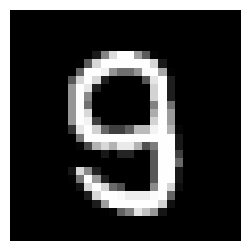

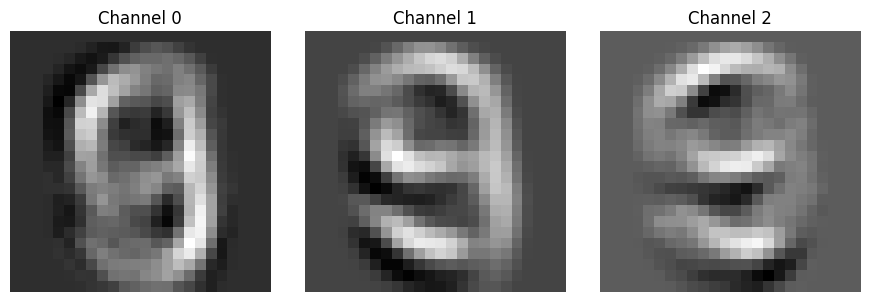

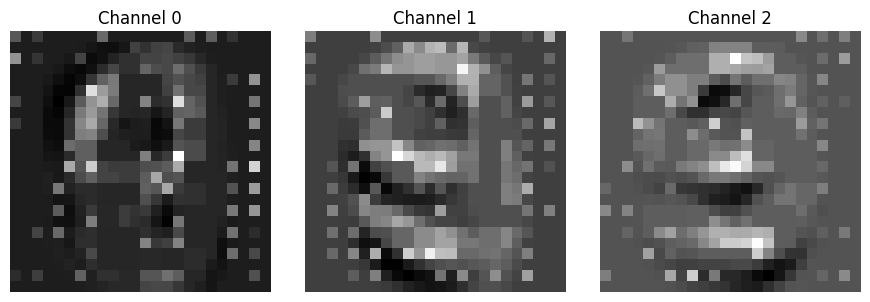

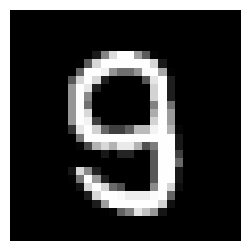

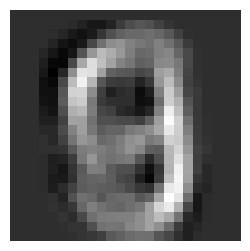

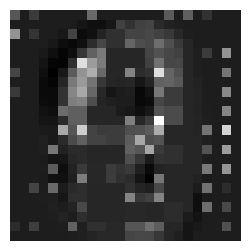

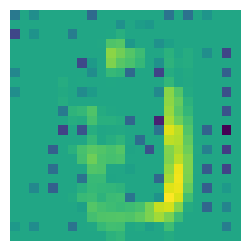

In [3]:
from pathlib import Path
from matplotlib import colormaps
from matplotlib.colors import BoundaryNorm
from models import SimpleCNN_mn

def find_misclassified_sample(model, dataset=test_set, device=DEVICE):
    """Iterate over misclassified samples of target_label in dataset order."""
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    model.eval()
    found = False
    with torch.no_grad():
        for sample_idx, (x, y) in enumerate(loader):
            label = int(y.item())
            x_dev = x.to(device)
            out = model(x_dev)["out"]
            pred = int(out.argmax(dim=1).item())
            if pred != label:
                found = True
                print(
                    f"找到第 {sample_idx} 个样本将类别 "
                    f"{label}错误分类成{pred} !"
                )
                yield sample_idx

MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/mnist/mn_simplecnnv2_relu_epoch30_0.9700.pth"
LAYER_NAME = "z1"     #  "z2" 

model = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
model.load_state_dict(torch.load(MODELPATH, map_location=DEVICE, weights_only=True))
model.eval()
# mis_iter = find_misclassified_sample(model)
SAMPLE_IDX = 241 #next(mis_iter)

image, label = test_set[SAMPLE_IDX]
image, label = image.unsqueeze(0).to(DEVICE), torch.tensor(label, device=DEVICE).unsqueeze(0)

with torch.no_grad():
    res = model(image)
    pred = res['out'].argmax(dim=1).item()
    forward_fea = res[LAYER_NAME][0]  # C,H,W
    recons_fea = model.get_recons_fea(input_data=image, label_data=label, recons_key=f"recons_{LAYER_NAME}")
image, forward_fea, recons_fea = image.squeeze(), forward_fea.squeeze(), recons_fea.squeeze()

print(image.shape, forward_fea.shape, recons_fea.shape)
print("label:", label.cpu(), "pred:", pred)

def denormalize_mnist(x):
    return x * 0.3081 + 0.1307

plt.figure(figsize=(3, 3))
plt.imshow(denormalize_mnist(image.cpu().numpy()), cmap="gray")
# plt.title(f"Sample {SAMPLE_IDX} | GT={label}, Pred={pred}")
plt.axis("off")
plt.show()

fea = forward_fea.detach().cpu()
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for c in range(3):
    axes[c].imshow(fea[c], cmap="gray")
    axes[c].set_title(f"Channel {c}")
    axes[c].axis("off")
plt.tight_layout()
plt.show()

fea = recons_fea.detach().cpu()
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for c in range(3):
    axes[c].imshow(fea[c], cmap="gray")
    axes[c].set_title(f"Channel {c}")
    axes[c].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 3))
plt.imshow(denormalize_mnist(image.cpu().numpy()), cmap="gray")
plt.axis("off")
plt.savefig("mnist_example/original.png", dpi=600)
plt.figure(figsize=(3, 3))
plt.imshow(forward_fea.detach().cpu()[0], cmap="gray")
plt.axis("off")
plt.savefig("mnist_example/forward.png", dpi=600)
plt.figure(figsize=(3, 3))
plt.imshow(recons_fea.detach().cpu()[0], cmap="gray")
plt.axis("off")
plt.savefig("mnist_example/recons.png", dpi=600)
plt.figure(figsize=(3, 3))
plt.imshow(forward_fea.detach().cpu()[0]-recons_fea.detach().cpu()[0], cmap="viridis")
plt.axis("off")
plt.savefig("mnist_example/diff.png", dpi=600)

[DEBUG fft] spectral fallback used for 53/144 frequency systems


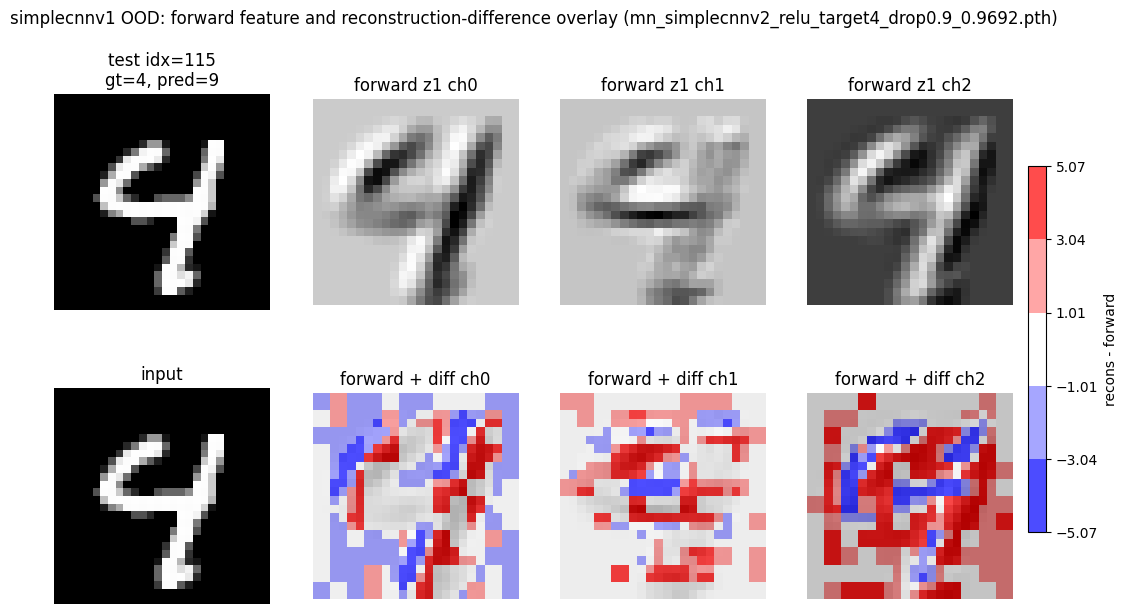

sample_idx=115, gt=4, pred=9, logits=[-1.5420000553131104, -10.032999992370605, -3.8010001182556152, -2.053999900817871, 12.362000465393066, -4.216000080108643, -9.569000244140625, 1.0709999799728394, 4.453999996185303, 13.20199966430664]
diff mean=0.758143, diff min=-8.380793, diff max=15.359871


In [4]:
from pathlib import Path
from matplotlib import colormaps
from matplotlib.colors import BoundaryNorm
from models import SimpleCNN_mn
OOD_FEATURE_NAME = "z1"  # simplecnnv2 可选: "z1" 或 "z2"
OOD_ALPHA = 0.7
OOD_DIFF_PERCENTILE = 0.9
OOD_HEATMAP_LEVELS = 5

OOD_TARGET_LABEL = 4
OOD_MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts_ood/mnist/mn_simplecnnv2_relu_target4_drop0.9_0.9692.pth"
model_ood = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
model_ood.load_state_dict(torch.load(OOD_MODELPATH, map_location=DEVICE, weights_only=True))
model_ood.eval()

def find_misclassified_sample(model, dataset, target_label=OOD_TARGET_LABEL, device=DEVICE):
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    model.eval()
    with torch.no_grad():
        for sample_idx, (x, y) in enumerate(loader):
            x_dev = x.to(device)
            out = model(x_dev)["out"]
            pred = int(out.argmax(dim=1).item())
            # return sample_idx, x_dev, int(y.item()), pred, out.detach().cpu()
            if int(y.item()) != target_label: continue
            if pred != target_label:
                return sample_idx, x_dev, int(y.item()), pred, out.detach().cpu()
    raise RuntimeError(f"测试集中没有找到 gt={target_label} 且被当前模型错分的样本。")

def normalize_map(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().float()
    x_min, x_max = x.min(), x.max()
    return (x - x_min) / (x_max - x_min + 1e-12)

def visualize_forward_with_recons_diff(model, dataset, target_label=4, feature_name="z2"):
    sample_idx, input_data, label, pred, logits = find_misclassified_sample(model, dataset, target_label)

    with torch.no_grad():
        forward_res = model(input_data)
        recons_res = model.get_recons_fea(input_data, torch.tensor([label], device=input_data.device))

    forward_feature = forward_res[feature_name].detach().cpu().squeeze(0)
    recons_feature = recons_res[f"recons_{feature_name}"].detach().cpu().squeeze(0)
    assert forward_feature.shape == recons_feature.shape, (forward_feature.shape, recons_feature.shape)

    diff = recons_feature - forward_feature
    diff_quantile = OOD_DIFF_PERCENTILE / 100 if OOD_DIFF_PERCENTILE > 1 else OOD_DIFF_PERCENTILE
    vmax = torch.quantile(diff.abs().flatten(), diff_quantile).item()
    vmax = max(vmax, diff.abs().max().item() * 1e-6, 1e-12)

    num_channels = forward_feature.size(0)
    bounds = np.linspace(-vmax, vmax, OOD_HEATMAP_LEVELS + 1)
    cmap = colormaps["bwr"].resampled(OOD_HEATMAP_LEVELS)
    norm = BoundaryNorm(bounds, cmap.N, clip=True)
    fig, axes = plt.subplots(2, num_channels + 1, figsize=(3.2 * (num_channels + 1), 7.0), squeeze=False)

    axes[0, 0].imshow(input_data.detach().cpu().squeeze().numpy(), cmap="gray")
    axes[0, 0].set_title(f"test idx={sample_idx}\ngt={label}, pred={pred}")
    axes[0, 0].set_ylabel("input / forward", fontsize=11)
    axes[0, 0].axis("off")

    axes[1, 0].imshow(input_data.detach().cpu().squeeze().numpy(), cmap="gray")
    axes[1, 0].set_title("input")
    axes[1, 0].set_ylabel("forward + diff", fontsize=11)
    axes[1, 0].axis("off")

    im = None
    for c in range(num_channels):
        base = normalize_map(forward_feature[c]).numpy()
        channel_diff = diff[c].numpy()

        ax_forward = axes[0, c + 1]
        ax_forward.imshow(base, cmap="gray")
        ax_forward.set_title(f"forward {feature_name} ch{c}")
        ax_forward.axis("off")

        ax_overlay = axes[1, c + 1]
        ax_overlay.imshow(base, cmap="gray")
        im = ax_overlay.imshow(channel_diff, cmap=cmap, norm=norm, alpha=OOD_ALPHA)
        ax_overlay.set_title(f"forward + diff ch{c}")
        ax_overlay.axis("off")

    cbar = fig.colorbar(im, ax=axes[:, 1:].ravel().tolist(), fraction=0.025, pad=0.02)
    cbar.set_label("recons - forward")
    fig.suptitle(f"simplecnnv1 OOD: forward feature and reconstruction-difference overlay ({Path(OOD_MODELPATH).name})")
    plt.show()
    print(f"sample_idx={sample_idx}, gt={label}, pred={pred}, logits={logits.numpy().round(3).tolist()[0]}")
    print(f"diff mean={diff.mean().item():.6f}, diff min={diff.min().item():.6f}, diff max={diff.max().item():.6f}")

visualize_forward_with_recons_diff(model_ood, test_set, OOD_TARGET_LABEL, OOD_FEATURE_NAME)


[DEBUG fft] spectral fallback used for 37/144 frequency systems
[DEBUG fft] spectral fallback used for 37/144 frequency systems


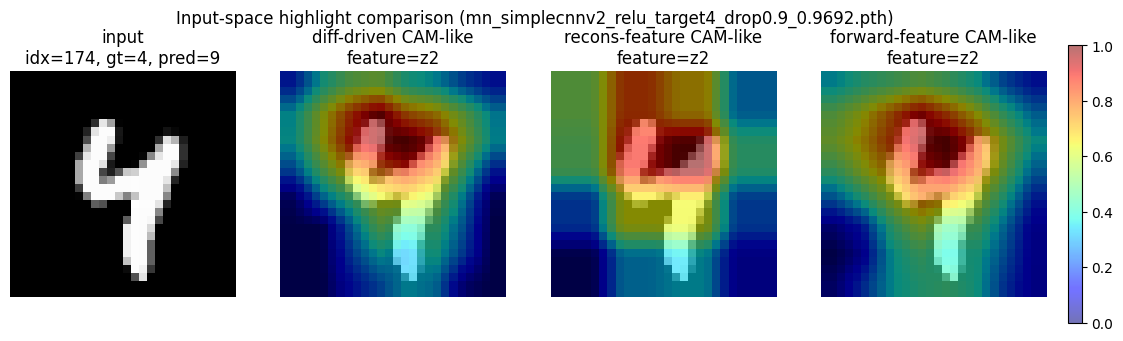

sample_idx=174, gt=4, pred=9, logits=[-6.2179999351501465, -6.521999835968018, -7.189000129699707, -1.600000023841858, 8.77400016784668, -4.558000087738037, -4.301000118255615, -0.24799999594688416, 3.191999912261963, 9.090999603271484]
diff mean=2.543431, diff min=-0.067695, diff max=11.049081


In [11]:
import torch.nn.functional as F

CAM_ALPHA = 0.55
CAM_CMAP = "jet"
OOD_FEATURE_NAME = 'z2'   # TODO 可选: "z1", "z2", "out"
CAM_DIFF_FEATURE_NAME = OOD_FEATURE_NAME    
CAM_RECONS_FEATURE_NAME = OOD_FEATURE_NAME  
CAM_FORWARD_FEATURE_NAME = OOD_FEATURE_NAME 

def tensor_to_numpy_img(x):
    x = x.detach().cpu().squeeze().float()
    return normalize_map(x).numpy()

def upsample_cam(cam, input_data):
    cam = F.interpolate(
        cam,
        size=input_data.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )
    cam = cam.squeeze().detach().cpu().float()
    return normalize_map(cam).numpy()

def get_diff_driven_cam(model, input_data, label, feature_name="z2"):
    model.eval()
    recons_key = f"recons_{feature_name}"

    if feature_name == "out":
        x = input_data.detach().clone().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        forward_out = model(x)["out"]
        recons_out = model.get_recons_fea(x, torch.tensor([label], device=x.device))[recons_key]
        diff = recons_out - forward_out

        # out 没有空间维度：用 gt 对应 logit 的有符号 diff 对输入求梯度，得到输入空间高亮。
        score = diff[0, label]
        score.backward()
        saliency = x.grad.detach().abs().amax(dim=1, keepdim=True)
        return upsample_cam(saliency, input_data), diff.detach().cpu()

    with torch.no_grad():
        forward_res = model(input_data)
        recons_res = model.get_recons_fea(input_data, torch.tensor([label], device=input_data.device))

    forward_feature = forward_res[feature_name]
    recons_feature = recons_res[recons_key]
    diff = recons_feature - forward_feature

    if diff.dim() != 4:
        raise ValueError(f"diff for {feature_name} has shape {tuple(diff.shape)}; expected a 4D feature map or feature_name='out'.")

    # CAM-like: 用每个 channel 的平均有符号重建差作为 channel 权重，再加权当前位置的 forward feature。
    weights = diff.mean(dim=(2, 3), keepdim=True)
    cam_signed = (weights * forward_feature).sum(dim=1, keepdim=True)
    cam = F.relu(cam_signed)

    # 如果正向部分全为 0，就退回到绝对贡献，避免图完全空白。
    if cam.max().item() <= 1e-12:
        cam = cam_signed.abs()
    return upsample_cam(cam, input_data), diff.detach().cpu()

def feature_map_to_cam(feature, input_data):
    # CAM-like: 用特征图自己的 channel 均值作为权重，在该特征图上做加权求和。
    weights = feature.mean(dim=(2, 3), keepdim=True)
    cam_signed = (weights * feature).sum(dim=1, keepdim=True)
    # cam = F.relu(cam_signed)
    cam = cam_signed

    if cam.max().item() <= 1e-12:
        cam = cam_signed.abs()
    return upsample_cam(cam, input_data)

def get_recons_feature_cam(model, input_data, label, feature_name="z2"):
    model.eval()
    recons_key = f"recons_{feature_name}"

    if feature_name == "out":
        x = input_data.detach().clone().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        recons_out = model.get_recons_fea(x, torch.tensor([label], device=x.device))[recons_key]
        score = recons_out[0, label]
        score.backward()
        saliency = x.grad.detach().abs().amax(dim=1, keepdim=True)
        return upsample_cam(saliency, input_data)

    with torch.no_grad():
        recons_res = model.get_recons_fea(input_data, torch.tensor([label], device=input_data.device))
    recons_feature = recons_res[recons_key]

    if recons_feature.dim() != 4:
        raise ValueError(f"{recons_key} has shape {tuple(recons_feature.shape)}; expected a 4D feature map or feature_name='out'.")
    return feature_map_to_cam(recons_feature, input_data)

def get_forward_feature_cam(model, input_data, feature_name="z1", class_idx=None):
    model.eval()

    if feature_name == "out":
        if class_idx is None:
            with torch.no_grad():
                class_idx = int(model(input_data)["out"].argmax(dim=1).item())
        x = input_data.detach().clone().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        score = model(x)["out"][0, class_idx]
        score.backward()
        saliency = x.grad.detach().abs().amax(dim=1, keepdim=True)
        return upsample_cam(saliency, input_data)

    with torch.no_grad():
        forward_feature = model(input_data)[feature_name]

    if forward_feature.dim() != 4:
        raise ValueError(f"forward feature {feature_name} has shape {tuple(forward_feature.shape)}; expected a 4D feature map or feature_name='out'.")
    return feature_map_to_cam(forward_feature, input_data)

def visualize_input_cam_compare(model, dataset, target_label=4, diff_feature_name="z2", recons_feature_name="z2", forward_feature_name="z2"):
    sample_idx, input_data, label, pred, logits = find_misclassified_sample(model, dataset, target_label)
    diff_cam, diff = get_diff_driven_cam(model, input_data, label, diff_feature_name)
    recons_cam = get_recons_feature_cam(model, input_data, label, recons_feature_name)
    forward_cam = get_forward_feature_cam(model, input_data, forward_feature_name, class_idx=pred)
    input_img = tensor_to_numpy_img(input_data)

    fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.6), squeeze=False)

    axes[0, 0].imshow(input_img, cmap="gray")
    axes[0, 0].set_title(f"input\nidx={sample_idx}, gt={label}, pred={pred}")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(input_img, cmap="gray")
    im1 = axes[0, 1].imshow(diff_cam, cmap=CAM_CMAP, alpha=CAM_ALPHA, vmin=0, vmax=1)
    axes[0, 1].set_title(f"diff-driven CAM-like\nfeature={diff_feature_name}")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(input_img, cmap="gray")
    im2 = axes[0, 2].imshow(recons_cam, cmap=CAM_CMAP, alpha=CAM_ALPHA, vmin=0, vmax=1)
    axes[0, 2].set_title(f"recons-feature CAM-like\nfeature={recons_feature_name}")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(input_img, cmap="gray")
    im3 = axes[0, 3].imshow(forward_cam, cmap=CAM_CMAP, alpha=CAM_ALPHA, vmin=0, vmax=1)
    axes[0, 3].set_title(f"forward-feature CAM-like\nfeature={forward_feature_name}")
    axes[0, 3].axis("off")

    fig.colorbar(im3, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    fig.suptitle(f"Input-space highlight comparison ({Path(OOD_MODELPATH).name})")
    plt.show()

    print(f"sample_idx={sample_idx}, gt={label}, pred={pred}, logits={logits.numpy().round(3).tolist()[0]}")
    print(f"diff mean={diff.mean().item():.6f}, diff min={diff.min().item():.6f}, diff max={diff.max().item():.6f}")

visualize_input_cam_compare(model_ood, test_set, OOD_TARGET_LABEL, CAM_DIFF_FEATURE_NAME, CAM_RECONS_FEATURE_NAME, CAM_FORWARD_FEATURE_NAME)


## different stage vs recons loss

In [ ]:
from models import SimpleCNN_mn
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) 
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False) 
print(len(train_loader), len(test_loader))

def get_score(model, data_loader, DEVICE=DEVICE):
    model.eval()  # Set the module in evaluation mode.
    correct = 0.0   # 正确率
    with torch.no_grad():  # 不会进行计算梯度，也不会进行反向传播
        for data, target in data_loader:
            data = data.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            output = model(data)['out']
            pred = output.argmax(dim=1)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return correct/len(data_loader.dataset)    

def get_recons_loss(model, data_loader, DEVICE=DEVICE):
    """Return the sample-averaged reconstruction loss on data_loader."""
    model.eval()
    sample_num = 0
    recons_loss = {recons_key: 0.0 for recons_key in model.get_fea_name()}
    with torch.no_grad():
        for input, target in data_loader:
            input = input.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            recons_feature = model.get_recons_fea(input.detach(), target, recons_key=None)
            res = model(input)
            bs = input.size(0)
            sample_num += bs
            for recons_key in model.get_fea_name():
                diff = res[recons_key[7:]] - recons_feature[recons_key]  # 
                reconsloss_batch = diff.flatten(1).pow(2).sum(dim=1).sum()
                recons_loss[recons_key] += reconsloss_batch.item()
    return {recons_key: loss / sample_num for recons_key, loss in recons_loss.items()}


def train_stage_recons(model, lr, num_epochs, train_record=True, every_epoch=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    clscrit = nn.CrossEntropyLoss()
    recons_keys = model.get_fea_name()

    train_score_list, test_score_list = [], []
    train_recons_loss_list = {recons_key: [] for recons_key in recons_keys}
    test_recons_loss_list = {recons_key: [] for recons_key in recons_keys}

    for epoch in range(num_epochs):
        if epoch % every_epoch == 0:
            print("************* ", end="")
            test_score = get_score(model, test_loader, DEVICE)
            test_score_list.append(test_score)
            test_recons_loss = get_recons_loss(model, test_loader, DEVICE)
            for recons_key in recons_keys:
                test_recons_loss_list[recons_key].append(test_recons_loss[recons_key])

            if train_record:
                train_score = get_score(model, train_loader, DEVICE)
                train_score_list.append(train_score)
                train_recons_loss = get_recons_loss(model, train_loader, DEVICE)
                for recons_key in recons_keys:
                    train_recons_loss_list[recons_key].append(train_recons_loss[recons_key])
                print(  f"Epoch [{epoch + 1}/{num_epochs}] "
                        f"train_score={train_score:.4f}, test_score={test_score:.4f}, "
                        f"train_recons_loss={train_recons_loss}, test_recons_loss={test_recons_loss}")
            else:
                print(f"Epoch [{epoch + 1}/{num_epochs}] test_score={test_score:.4f}, "
                    f"test_recons_loss={test_recons_loss}")
        model.train()
        for data, target in train_loader:
            data = data.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            loss = clscrit(model(data)["out"], target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    print("************* ", end="")
    test_score = get_score(model, test_loader, DEVICE)
    test_score_list.append(test_score)
    test_recons_loss = get_recons_loss(model, test_loader, DEVICE)
    for recons_key in recons_keys:
        test_recons_loss_list[recons_key].append(test_recons_loss[recons_key])
    if train_record:
        train_score = get_score(model, train_loader, DEVICE)
        train_score_list.append(train_score)
        train_recons_loss = get_recons_loss(model, train_loader, DEVICE)
        for recons_key in recons_keys:
            train_recons_loss_list[recons_key].append(train_recons_loss[recons_key])
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"train_score={train_score:.4f}, test_score={test_score:.4f}, "
            f"train_recons_loss={train_recons_loss}, test_recons_loss={test_recons_loss}"
        )
    else:
        print( f"Epoch [{epoch + 1}/{num_epochs}] test_score={test_score:.4f}, "
               f"test_recons_loss={test_recons_loss}")
        
    results = {
        "model": model.name,
        "lr": lr,
        "num_epochs": num_epochs,
        "recons_keys": recons_keys,
        "train_score_list": train_score_list,
        "test_score_list": test_score_list,
        "train_recons_loss_list": train_recons_loss_list,
        "test_recons_loss_list": test_recons_loss_list,
    }

    ckpt_path = Path(f"/data/dn/FRTP_revision1/imagecls/logs_stage/{model.name}_{lr}lr_{num_epochs}e.pth")
    torch.save({k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, ckpt_path)
    print(f"saved model ckpt to {ckpt_path}")

    save_path = Path(f"/data/dn/FRTP_revision1/imagecls/logs_stage/{model.name}_{lr}lr_{num_epochs}e.pt")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(results, save_path)
    print(f"saved results to {save_path}")
    print("train_score_list =", train_score_list)
    print("test_score_list =", test_score_list)
    print("train_recons_loss_list =", train_recons_loss_list)
    print("test_recons_loss_list =", test_recons_loss_list)
    return results


235 40


In [ ]:
MODELPATH = None
LR = 1e-3
EPOCHS = 30
EVERY_EPOCH = 5

model = SimpleCNN_mn(activate=torch.relu, version="v2").to(DEVICE)
if MODELPATH is not None:
    ckpt = torch.load(MODELPATH, map_location=DEVICE, weights_only=True)
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    model.load_state_dict(ckpt)
stage_recons_results = train_stage_recons(model, lr=LR, num_epochs=EPOCHS, every_epoch=EVERY_EPOCH)
train_score_list = stage_recons_results["train_score_list"]
test_score_list = stage_recons_results["test_score_list"]
train_recons_loss_list = stage_recons_results["train_recons_loss_list"]
test_recons_loss_list = stage_recons_results["test_recons_loss_list"]

************* [DEBUG fft] spectral fallback used for 40/144 frequency systems
[DEBUG fft] spectral fallback used for 46/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 42/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 42/144 frequency systems
[DEBUG fft] spectral fallback used for 50/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 42/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 42/144 frequency systems
[DEBUG fft] spectral fallback used for 44/144 frequency systems
[DEBUG fft] spectral fallback used for 46/144 frequency systems
[DEBUG fft] spectral fallb